## Viernes 18 de setiembre
## Trabajo Asincrónico

### Estudiante: Katherine Susana Rojas Saborío
Grupo 04

1. Preparación del archivo y la variable objetivo

In [18]:
# Importar librerías
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, classification_report

# Cargar los archivos
uploaded = files.upload()

nombre_archivo = list(uploaded.keys())[0]

df = pd.read_excel(nombre_archivo, sheet_name=0)
df = df.dropna(axis=1, how="all")  # quita columnas vacías
df.columns = [str(c).strip() for c in df.columns]

col_fecha = [c for c in df.columns if "Fecha" in c][0]
df[col_fecha] = pd.to_datetime(df[col_fecha])
df = df.sort_values(col_fecha).reset_index(drop=True)

cols_numeros = [c for c in df.columns if "Número" in c and "Sorteo" not in c]
print(f"{len(df)} sorteos cargados, del {df[col_fecha].min().date()} al {df[col_fecha].max().date()}")
print(df.head())

#Convertir a formato "Tabla binaria"
rango_numeros = list(range(100))
binaria = pd.DataFrame(0, index=df.index, columns=rango_numeros)
for c in cols_numeros:
    for idx, val in df[c].items():
        if pd.notna(val):
            binaria.loc[idx, int(val)] = 1
binaria.head()

#Crear las variable (features)
VENTANA = 20
N_SORTEOS = 500

muestra = binaria.tail(N_SORTEOS).reset_index(drop=True)
X = pd.DataFrame({
    f"freq_{num}": muestra[num].rolling(VENTANA, min_periods=1).mean().shift(1).fillna(0)
    for num in rango_numeros
})
y = muestra


Saving Numeros_Favoreecidos_2019_2025.xlsx to Numeros_Favoreecidos_2019_2025 (4).xlsx
569 sorteos cargados, del 2019-01-04 al 2025-12-02
   Número Sorteo Fecha Sorteo  Primer Número  Primer Serie  Segundo Número  \
0           6360   2019-01-04             41           202              53   
1           6361   2019-01-08             16           831              37   
2           6362   2019-01-11             18           213              54   
3           6363   2019-01-15             34           396               5   
4           6364   2019-01-18             78           424              11   

   Segunda Serie  Tercer Número  Tercer Serie  
0            945             84           840  
1            514             52           525  
2            699             50           236  
3            415             31           723  
4            754             49           141  


2. Preparación de los datos para el entrenamiento

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

resultados = {}

### 3. Entrenamiento de los modelos para decidir cuál nos va a dar el mejor resultado

a. Regresión logística

In [20]:
from sklearn.metrics import accuracy_score

print(f"Regresión Logística")
modelo_lr = MultiOutputClassifier(LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
modelo_lr.fit(X_train, y_train)

pred_lr = modelo_lr.predict(X_test)
pred_proba_lr = modelo_lr.predict_proba(X_test)

# Exactitud / Precisión
exactitud_lr = accuracy_score(y_test.values.ravel(), pred_lr.ravel())
exactitud_azar = 3 / 100
print(f"Exactitud del modelo: {exactitud_lr:.2%}")
print(f"Exactitud esperada solo por azar: {exactitud_azar:.2%}")

# AUC-ROC
probs_lr = np.array([p[:, 1] if p.shape[1] == 2 else np.zeros(p.shape[0]) for p in pred_proba_lr]).T
auc_lr = roc_auc_score(y_test, probs_lr, average='micro')
print(f"AUC Score: {auc_lr:.4f}\n")

# Reporte de la evaluación por número
nombres_clases = [f"Número {i:02d}" for i in range(100)]
print(classification_report(y_test, pred_lr, target_names=nombres_clases, zero_division=0))


resultados["Regresión Logística"] = [
    precision_score(y_test, pred_lr, average='micro', zero_division=0),
    recall_score(y_test, pred_lr, average='micro', zero_division=0),
    f1_score(y_test, pred_lr, average='micro', zero_division=0),
    auc_lr
]


Regresión Logística
Exactitud del modelo: 86.54%
Exactitud esperada solo por azar: 3.00%
AUC Score: 0.5248

              precision    recall  f1-score   support

   Número 00       0.00      0.00      0.00         2
   Número 01       0.04      0.50      0.08         4
   Número 02       0.04      0.20      0.07         5
   Número 03       0.00      0.00      0.00         2
   Número 04       0.00      0.00      0.00         1
   Número 05       0.00      0.00      0.00         1
   Número 06       0.00      0.00      0.00         3
   Número 07       0.00      0.00      0.00         5
   Número 08       0.00      0.00      0.00         4
   Número 09       0.03      0.33      0.05         3
   Número 10       0.00      0.00      0.00         2
   Número 11       0.00      0.00      0.00         3
   Número 12       0.00      0.00      0.00         5
   Número 13       0.03      0.50      0.06         2
   Número 14       0.00      0.00      0.00         5
   Número 15       0.00    

b. Árbol de Decisión (Decision Tree)

In [21]:
print(f"Decision Tree")
modelo_dt = MultiOutputClassifier(DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42))
modelo_dt.fit(X_train, y_train)

pred_dt = modelo_dt.predict(X_test)
pred_proba_dt = modelo_dt.predict_proba(X_test)

# # Exactitud / Precisión
exactitud_dt = accuracy_score(y_test.values.ravel(), pred_dt.ravel())
print(f"Exactitud del modelo: {exactitud_dt:.2%}")
print(f"Exactitud esperada solo por azar: {exactitud_azar:.2%}")

# AUC-ROC
probs_dt = np.array([p[:, 1] if p.shape[1] == 2 else np.zeros(p.shape[0]) for p in pred_proba_dt]).T
auc_dt = roc_auc_score(y_test, probs_dt, average='micro')
print(f"AUC Score: {auc_dt:.4f}\n")

# Reporte de la evaluación por número
print(classification_report(y_test, pred_dt, target_names=nombres_clases, zero_division=0))


resultados["Árbol de Decisión"] = [
    precision_score(y_test, pred_dt, average='micro', zero_division=0),
    recall_score(y_test, pred_dt, average='micro', zero_division=0),
    f1_score(y_test, pred_dt, average='micro', zero_division=0),
    auc_dt
]

Decision Tree
Exactitud del modelo: 76.68%
Exactitud esperada solo por azar: 3.00%
AUC Score: 0.5146

              precision    recall  f1-score   support

   Número 00       0.10      1.00      0.18         2
   Número 01       0.07      0.50      0.12         4
   Número 02       0.06      0.20      0.10         5
   Número 03       0.00      0.00      0.00         2
   Número 04       0.00      0.00      0.00         1
   Número 05       0.00      0.00      0.00         1
   Número 06       0.03      0.33      0.05         3
   Número 07       0.07      0.20      0.10         5
   Número 08       0.00      0.00      0.00         4
   Número 09       0.05      0.67      0.10         3
   Número 10       0.00      0.00      0.00         2
   Número 11       0.00      0.00      0.00         3
   Número 12       0.12      0.20      0.15         5
   Número 13       0.03      0.50      0.05         2
   Número 14       0.00      0.00      0.00         5
   Número 15       0.00      0.00

c. Random Forest

In [22]:
print(f"Random Forest")
modelo_rf = MultiOutputClassifier(RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42))
modelo_rf.fit(X_train, y_train)

pred_rf = modelo_rf.predict(X_test)
pred_proba_rf = modelo_rf.predict_proba(X_test)

# Exactitud / Precisión
exactitud_rf = accuracy_score(y_test.values.ravel(), pred_rf.ravel())
print(f"Exactitud del modelo: {exactitud_rf:.2%}")
print(f"Exactitud esperada solo por azar: {exactitud_azar:.2%}")

# AUC-ROC
probs_rf = np.array([p[:, 1] if p.shape[1] == 2 else np.zeros(p.shape[0]) for p in pred_proba_rf]).T
auc_rf = roc_auc_score(y_test, probs_rf, average='micro')
print(f"AUC Score: {auc_rf:.4f}\n")

# Reporte evaluativo por número
print(classification_report(y_test, pred_rf, target_names=nombres_clases, zero_division=0))


resultados["Random Forest"] = [
    precision_score(y_test, pred_rf, average='micro', zero_division=0),
    recall_score(y_test, pred_rf, average='micro', zero_division=0),
    f1_score(y_test, pred_rf, average='micro', zero_division=0),
    auc_rf
]

Random Forest
Exactitud del modelo: 97.01%
Exactitud esperada solo por azar: 3.00%
AUC Score: 0.5093

              precision    recall  f1-score   support

   Número 00       0.00      0.00      0.00         2
   Número 01       0.00      0.00      0.00         4
   Número 02       0.00      0.00      0.00         5
   Número 03       0.00      0.00      0.00         2
   Número 04       0.00      0.00      0.00         1
   Número 05       0.00      0.00      0.00         1
   Número 06       0.00      0.00      0.00         3
   Número 07       0.00      0.00      0.00         5
   Número 08       0.00      0.00      0.00         4
   Número 09       0.00      0.00      0.00         3
   Número 10       0.00      0.00      0.00         2
   Número 11       0.00      0.00      0.00         3
   Número 12       0.00      0.00      0.00         5
   Número 13       0.00      0.00      0.00         2
   Número 14       0.00      0.00      0.00         5
   Número 15       0.00      0.00

### Visualzación de Desempeño de los modelos

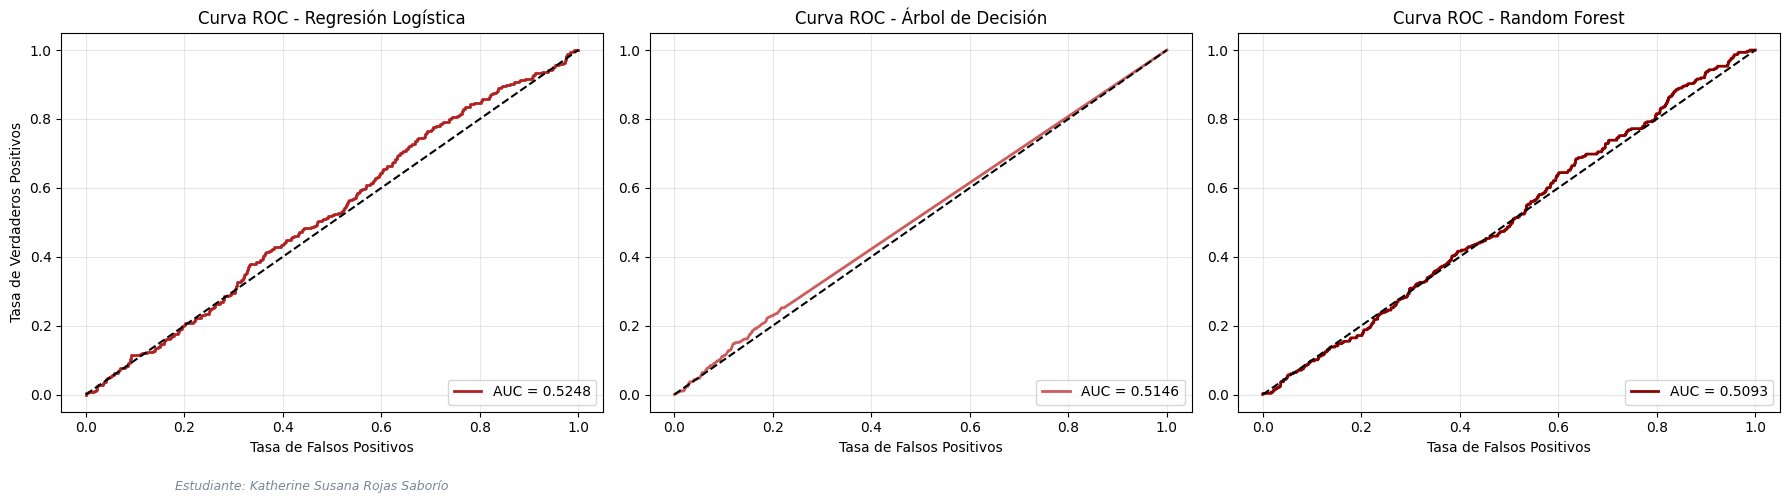

In [35]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

y_true_flat = y_test.values.ravel()

# 1. Gráfico: Regresión Logística
fpr_lr, tpr_lr, _ = roc_curve(y_true_flat, probs_lr.ravel())
axes[0].plot(fpr_lr, tpr_lr, color='firebrick', lw=2, label=f'AUC = {auc_lr:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5)
axes[0].set_title('Curva ROC - Regresión Logística')
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# 2. Gráfico: Árbol de Decisión
fpr_dt, tpr_dt, _ = roc_curve(y_true_flat, probs_dt.ravel())
axes[1].plot(fpr_dt, tpr_dt, color='indianred', lw=2, label=f'AUC = {auc_dt:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5)
axes[1].set_title('Curva ROC - Árbol de Decisión')
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

# 3. Gráfico: Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_true_flat, probs_rf.ravel())
axes[2].plot(fpr_rf, tpr_rf, color='darkred', lw=2, label=f'AUC = {auc_rf:.4f}')
axes[2].plot([0, 1], [0, 1], 'k--', lw=1.5)
axes[2].set_title('Curva ROC - Random Forest')
axes[2].set_xlabel('Tasa de Falsos Positivos')
axes[2].legend(loc='lower right')
axes[2].grid(alpha=0.3)



plt.figtext(0.1, 0.01, "Estudiante: Katherine Susana Rojas Saborío",
            fontsize=9, style='italic', color='lightslategray')


plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

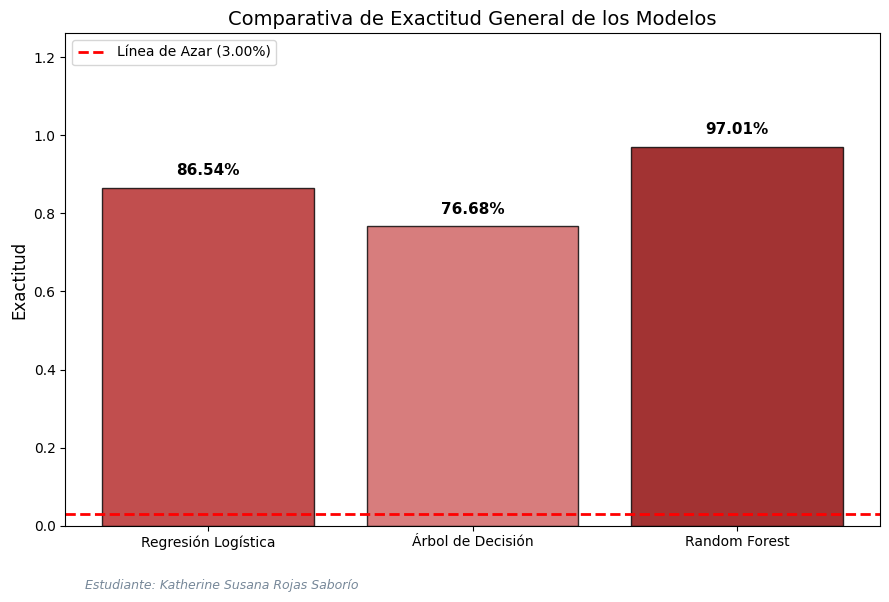

In [34]:
fig, ax = plt.subplots(figsize=(9, 6))

nombres = ['Regresión Logística', 'Árbol de Decisión', 'Random Forest']
exactitudes = [exactitud_lr, exactitud_dt, exactitud_rf]
colores = ['firebrick', 'indianred', 'darkred']

bars = ax.bar(nombres, exactitudes, color=colores, alpha=0.8, edgecolor='black')

# Línea base del azar (3%)
ax.axhline(y=exactitud_azar, color='red', linestyle='--', linewidth=2,
           label=f'Línea de Azar ({exactitud_azar:.2%})')

ax.set_title('Comparativa de Exactitud General de los Modelos', fontsize=14)
ax.set_ylabel('Exactitud', fontsize=12)

# Ajustar el límite superior para que la línea de azar y el texto se vean bien
limite_superior = max(max(exactitudes), exactitud_azar) * 1.3
ax.set_ylim(0, limite_superior)
ax.legend(loc='upper left')

# Imprimir los porcentajes arriba de cada barra
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + (limite_superior * 0.02),
            f'{yval:.2%}', ha='center', va='bottom', fontsize=11, fontweight='bold')


plt.figtext(0.1, 0.01, "Estudiante: Katherine Susana Rojas Saborío",
            fontsize=9, style='italic', color='lightslategray')


plt.tight_layout(rect=[0, 0.05, 1, 1])


plt.show()

Basado en el resultado de los modelos, el modelo más preciso es Random Forest, sin embargo, este modelo tiene el AUC-Score más bajo, y esto lo que hace es interpretar que tan al azar está siendo el resultado. 0.5 es muy al azar, 1 es tomando la decisión sin azar, con más certeza. El modelo con el mejor AUC-Score es el de Regresión Logística, pero aún así, se encuentra muy cercano al 0.5, y su precisión es de 86.54%, que no es tan malo. Se realizarán las predicciones con ambos.

In [38]:
ultimo_estado = X.tail(1)

# Predicción con Regresión Logística

probabilidades_lr = modelo_lr.predict_proba(ultimo_estado)
probs_clase_1_lr = np.array([p[0, 1] if p.shape[1] == 2 else 0.0 for p in probabilidades_lr])
top_10_lr = np.argsort(probs_clase_1_lr)[-10:][::-1]
mejor_num_lr = top_10_lr[0]

print("RESULTADOS DE LA FUTURA LOTERÍA (Haciéndole caso a Regresión Logística)")
print(f"El número que va a salir será: {mejor_num_lr:02d}")
print(f"Probabilidad estimada: {probs_clase_1_lr[mejor_num_lr]:.2%}\n")
print("Lista de 10 números con más posibilidad de salir:")
for i, num in enumerate(top_10_lr, 1):
    print(f" {i:2d}. Número {num:02d} | Prob: {probs_clase_1_lr[num]:.2%}")

print("------------------------------------------------------------------------")


# Predicción con Random Forest

probabilidades_rf = modelo_rf.predict_proba(ultimo_estado)
probs_clase_1_rf = np.array([p[0, 1] if p.shape[1] == 2 else 0.0 for p in probabilidades_rf])
top_10_rf = np.argsort(probs_clase_1_rf)[-10:][::-1]
mejor_num_rf = top_10_rf[0]

print("RESULTADOS DE LA FUTURA LOTERÍA (Haciéndole caso a Random Forest)")
print(f"El número que va a salir será: {mejor_num_rf:02d}")
print(f"Probabilidad estimada: {probs_clase_1_rf[mejor_num_rf]:.2%}\n")
print("Lista de 10 números con más posibilidad de salir:")
for i, num in enumerate(top_10_rf, 1):
    print(f" {i:2d}. Número {num:02d} | Prob: {probs_clase_1_rf[num]:.2%}")

RESULTADOS DE LA FUTURA LOTERÍA (Haciéndole caso a Regresión Logística)
El número que va a salir será: 97
Probabilidad estimada: 52.70%

Lista de 10 números con más posibilidad de salir:
  1. Número 97 | Prob: 52.70%
  2. Número 85 | Prob: 51.23%
  3. Número 67 | Prob: 51.20%
  4. Número 82 | Prob: 51.13%
  5. Número 57 | Prob: 50.85%
  6. Número 44 | Prob: 50.74%
  7. Número 10 | Prob: 49.98%
  8. Número 34 | Prob: 49.97%
  9. Número 08 | Prob: 49.81%
 10. Número 33 | Prob: 49.63%
------------------------------------------------------------------------
RESULTADOS DE LA FUTURA LOTERÍA (Haciéndole caso a Random Forest)
El número que va a salir será: 34
Probabilidad estimada: 34.70%

Lista de 10 números con más posibilidad de salir:
  1. Número 34 | Prob: 34.70%
  2. Número 82 | Prob: 28.82%
  3. Número 68 | Prob: 27.59%
  4. Número 03 | Prob: 26.77%
  5. Número 97 | Prob: 25.85%
  6. Número 74 | Prob: 25.35%
  7. Número 77 | Prob: 21.74%
  8. Número 55 | Prob: 21.65%
  9. Número 94 | Pr

### Visualización del comportamiento de la probabilidad según los datos históricos

Acá solo utilizamos Random Forest, porque es más exacto.

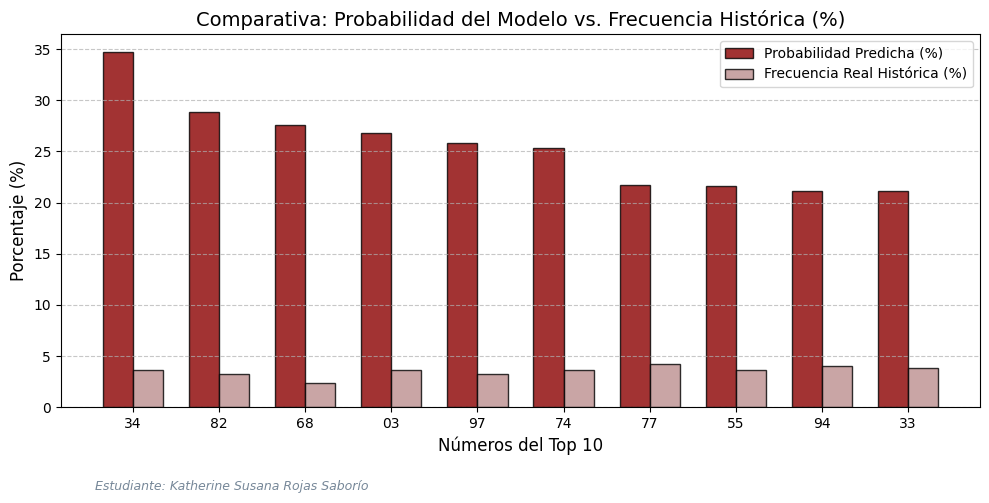

In [37]:
# Comparación del top 10 del resultado de Random Forest con su historial real en la muestra
top_10_numeros = top_10_rf
probabilidades_top = probs_clase_1_rf[top_10_numeros]

# Cálculo de cuántas veces ha salido cada número
conteo_historico = muestra[top_10_numeros].sum().values
porcentaje_historico = (conteo_historico / N_SORTEOS) * 100

# DF de la comparativa entre el número, la probabilidad y la frecuencia
df_comparativa = pd.DataFrame({
    'Número': [f"{num:02d}" for num in top_10_numeros],
    'Probabilidad Modelo (RF)': [f"{p:.2%}" for p in probabilidades_top],
    'Veces que ha salido': conteo_historico,
    'Frecuencia Histórica Real (%)': [f"{pct:.2f}%" for pct in porcentaje_historico]
})


# Gráfico de barras para visualizar la diferencia
fig, ax = plt.subplots(figsize=(10, 5))
x_indices = range(len(top_10_numeros))
width = 0.35

ax.bar([i - width/2 for i in x_indices], probabilidades_top * 100, width, label='Probabilidad Predicha (%)', color='darkred', alpha=0.8, edgecolor='black')
ax.bar([i + width/2 for i in x_indices], porcentaje_historico, width, label='Frecuencia Real Histórica (%)', color='rosybrown', alpha=0.8, edgecolor='black')

ax.set_xlabel('Números del Top 10', fontsize=12)
ax.set_ylabel('Porcentaje (%)', fontsize=12)
ax.set_title('Comparativa: Probabilidad del Modelo vs. Frecuencia Histórica (%)', fontsize=14)
ax.set_xticks(x_indices)
ax.set_xticklabels([f"{num:02d}" for num in top_10_numeros])
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)


plt.figtext(0.1, 0.01, "Estudiante: Katherine Susana Rojas Saborío",
            fontsize=9, style='italic', color='lightslategray')


plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.show()